# 3. Model Training

**Models:**
1. k-NN (k=5)
2. k-NN (k=15)
3. MLP (1 hidden layer, 64 neurons)
4. MLP (2 hidden layers, 32 neurons each)
5. MLP (1 hidden layer, 128 neurons, with dropout)

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, make_scorer
import joblib
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

# Config
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

## 3.1 Load Data

In [73]:
trainval = pd.read_csv('data/TRAINVAL_scaled.csv')
print(f"TRAINVAL: {trainval.shape}")

trainval_sub = pd.read_csv('data/TRAINVAL_subsample.csv')
print(f"TRAINVAL subsample: {trainval_sub.shape}")

TRAINVAL: (30160, 4007)
TRAINVAL subsample: (3016, 4007)


In [74]:
feature_cols = [c for c in trainval.columns if c.startswith('feat_')]

X_train = trainval[feature_cols].values
y_train = trainval['ml_target'].values

X_train_sub = trainval_sub[feature_cols].values
y_train_sub = trainval_sub['ml_target'].values

print(f"Full: X={X_train.shape}, y={y_train.shape}")
print(f"Subsample: X={X_train_sub.shape}, y={y_train_sub.shape}")

Full: X=(30160, 4005), y=(30160,)
Subsample: X=(3016, 4005), y=(3016,)


## 3.2 Model 1: k-NN (k=5)

In [75]:
knn_k5 = KNeighborsClassifier(n_neighbors=5, weights='distance', n_jobs=-1)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
scores = cross_val_score(knn_k5, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"CV AUC on full set: {scores.mean():.4f} (+/- {scores.std():.4f})")
f1_score = cross_val_score(knn_k5, X_train, y_train, cv=cv, scoring='f1')
print(f"CV F1-score: {f1_score.mean():.4f}")

knn_k5.fit(X_train, y_train)

os.makedirs('models', exist_ok=True)
joblib.dump(knn_k5, 'models/knn_k5.pkl')
print("Saved: models/knn_k5.pkl")

CV AUC on full set: 0.7285 (+/- 0.0052)
CV F1-score: 0.4626
Saved: models/knn_k5.pkl


## 3.3 Model 2: k-NN (k=15)

In [76]:
knn_k15 = KNeighborsClassifier(n_neighbors=15, weights='distance', n_jobs=-1)

scores = cross_val_score(knn_k15, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"CV AUC on full set: {scores.mean():.4f} (+/- {scores.std():.4f})")
f1_score = cross_val_score(knn_k15, X_train, y_train, cv=cv, scoring='f1')
print(f"CV F1-score: {f1_score.mean():.4f}")
knn_k15.fit(X_train, y_train)

joblib.dump(knn_k15, 'models/knn_k15.pkl')
print("Saved: models/knn_k15.pkl")

CV AUC on full set: 0.7946 (+/- 0.0074)
CV F1-score: 0.4080
Saved: models/knn_k15.pkl


## 3.4 Model 3: k-NN (k=30)

In [77]:
knn_k30 = KNeighborsClassifier(n_neighbors=30, weights='distance', n_jobs=-1)

scores = cross_val_score(knn_k30, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"CV AUC on full set: {scores.mean():.4f} (+/- {scores.std():.4f})")
f1_score = cross_val_score(knn_k30, X_train, y_train, cv=cv, scoring='f1')
print(f"CV F1-score: {f1_score.mean():.4f}")

knn_k30.fit(X_train, y_train)

joblib.dump(knn_k30, 'models/knn_k30.pkl')
print("Saved: models/knn_k30.pkl")

CV AUC on full set: 0.8330 (+/- 0.0035)
CV F1-score: 0.3040
Saved: models/knn_k30.pkl


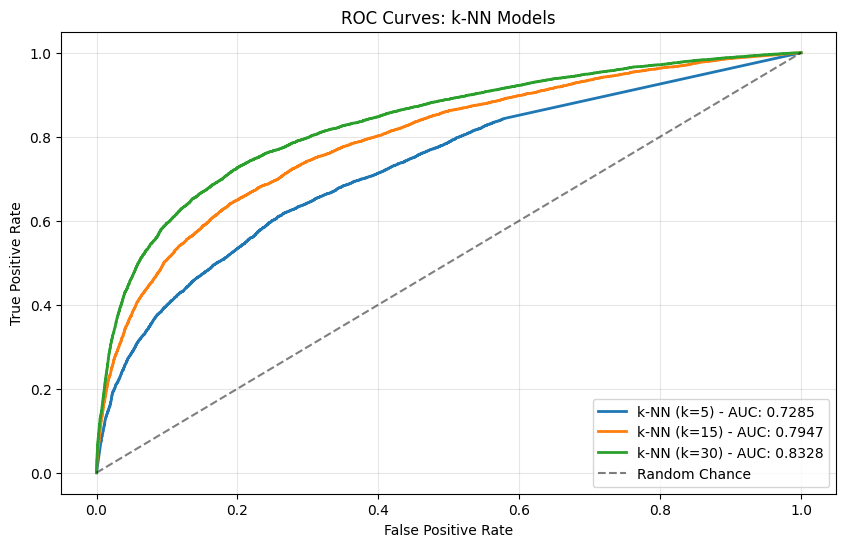

In [78]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_probs_k5 = cross_val_predict(knn_k5, X_train, y_train, cv=cv, method='predict_proba')
y_probs_k15 = cross_val_predict(knn_k15, X_train, y_train, cv=cv, method='predict_proba')
y_probs_k30 = cross_val_predict(knn_k30, X_train, y_train, cv=cv, method='predict_proba')

fpr_k5, tpr_k5, _ = roc_curve(y_train, y_probs_k5[:, 1])
roc_auc_k5 = auc(fpr_k5, tpr_k5)

fpr_k15, tpr_k15, _ = roc_curve(y_train, y_probs_k15[:, 1])
roc_auc_k15 = auc(fpr_k15, tpr_k15)

fpr_k30, tpr_k30, _ = roc_curve(y_train, y_probs_k30[:, 1])
roc_auc_k30 = auc(fpr_k30, tpr_k30)

plt.figure(figsize=(10, 6))

plt.plot(fpr_k5, tpr_k5, label=f'k-NN (k=5) - AUC: {roc_auc_k5:.4f}', linewidth=2)
plt.plot(fpr_k15, tpr_k15, label=f'k-NN (k=15) - AUC: {roc_auc_k15:.4f}', linewidth=2)
plt.plot(fpr_k30, tpr_k30, label=f'k-NN (k=30) - AUC: {roc_auc_k30:.4f}', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: k-NN Models')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

## 3.5 Model 4: MLP (1 layer, 64 neurons)

In [79]:
def build_mlp_v1(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc')]
    )
    return model

mlp_v1 = build_mlp_v1(X_train.shape[1])
mlp_v1.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_35 (Dense)                │ (None, 64)             │       256,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 256,449 (1001.75 KB)

 Trainable params: 256,449 (1001.75 KB)

 Non-trainable params: 0 (0.00 B)

In [80]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_v1 = mlp_v1.fit(
    X_train, y_train,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

mlp_v1.save('models/mlp_1layer_64.keras')
print("Saved: models/mlp_1layer_64.keras")

Epoch 1/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - auc: 0.7147 - loss: 0.8972 - val_auc: 0.8641 - val_loss: 0.5593
Epoch 2/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auc: 0.9239 - loss: 0.3977 - val_auc: 0.8796 - val_loss: 0.4611
Epoch 3/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - auc: 0.9581 - loss: 0.3133 - val_auc: 0.8816 - val_loss: 0.4525
Epoch 4/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - auc: 0.9722 - loss: 0.2708 - val_auc: 0.8814 - val_loss: 0.4570
Epoch 5/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - auc: 0.9796 - loss: 0.2422 - val_auc: 0.8793 - val_loss: 0.4676
Epoch 6/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - auc: 0.9851 - loss: 0.2191 - val_auc: 0.8774 - val_loss: 0.4809
Epoch 7/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - auc: 0.9885 - loss: 0.2011 - val_auc: 0.8754 - val_loss: 0.4920
Epoch 8/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - auc: 0.9915 - loss: 0.1849 - val_auc: 0.8757 - val_loss: 0.5003
Saved: models/mlp_1layer_64.keras


## 3.6 Model 5: MLP (2 layers, 32 neurons each)

In [81]:
def build_mlp_v2(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc')]
    )
    return model

mlp_v2 = build_mlp_v2(X_train.shape[1])
mlp_v2.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_37 (Dense)                │ (None, 32)             │       128,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,281 (505.00 KB)

 Trainable params: 129,281 (505.00 KB)

 Non-trainable params: 0 (0.00 B)

In [82]:
history_v2 = mlp_v2.fit(
    X_train, y_train,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

mlp_v2.save('models/mlp_2layer_32.keras')
print("Saved: models/mlp_2layer_32.keras")

Epoch 1/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - auc: 0.7239 - loss: 0.5985 - val_auc: 0.8856 - val_loss: 0.4245
Epoch 2/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.9297 - loss: 0.3584 - val_auc: 0.8861 - val_loss: 0.4273
Epoch 3/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.9607 - loss: 0.2866 - val_auc: 0.8822 - val_loss: 0.4585
Epoch 4/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.9748 - loss: 0.2424 - val_auc: 0.8763 - val_loss: 0.5017
Epoch 5/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.9844 - loss: 0.2056 - val_auc: 0.8714 - val_loss: 0.5544
Epoch 6/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - auc: 0.9908 - loss: 0.1740 - val_auc: 0.8656 - val_loss: 0.6183
Saved: models/mlp_2layer_32.keras


## 3.7 Model 6: MLP (1 layer, 128 neurons, dropout)

In [83]:
def build_mlp_v3(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc')]
    )
    return model

mlp_v3 = build_mlp_v3(X_train.shape[1])
mlp_v3.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 128)            │       512,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 512,897 (1.96 MB)

 Trainable params: 512,897 (1.96 MB)

 Non-trainable params: 0 (0.00 B)

In [84]:
history_v3 = mlp_v3.fit(
    X_train, y_train,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

mlp_v3.save('models/mlp_1layer_128_dropout.keras')
print("Saved: models/mlp_1layer_128_dropout.keras")

Epoch 1/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - auc: 0.7137 - loss: 0.7783 - val_auc: 0.8610 - val_loss: 0.4394
Epoch 2/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - auc: 0.9026 - loss: 0.3538 - val_auc: 0.8728 - val_loss: 0.4076
Epoch 3/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - auc: 0.9484 - loss: 0.2516 - val_auc: 0.8719 - val_loss: 0.4294
Epoch 4/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auc: 0.9672 - loss: 0.2039 - val_auc: 0.8701 - val_loss: 0.4573
Epoch 5/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auc: 0.9780 - loss: 0.1719 - val_auc: 0.8672 - val_loss: 0.4944
Epoch 6/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auc: 0.9845 - loss: 0.1467 - val_auc: 0.8674 - val_loss: 0.5251
Epoch 7/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - auc: 0.9883 - loss: 0.1284 - val_auc: 0.8647 - val_loss: 0.5635
Saved: models/mlp_1layer_128_dropout.keras


## 3.7 Training Summary

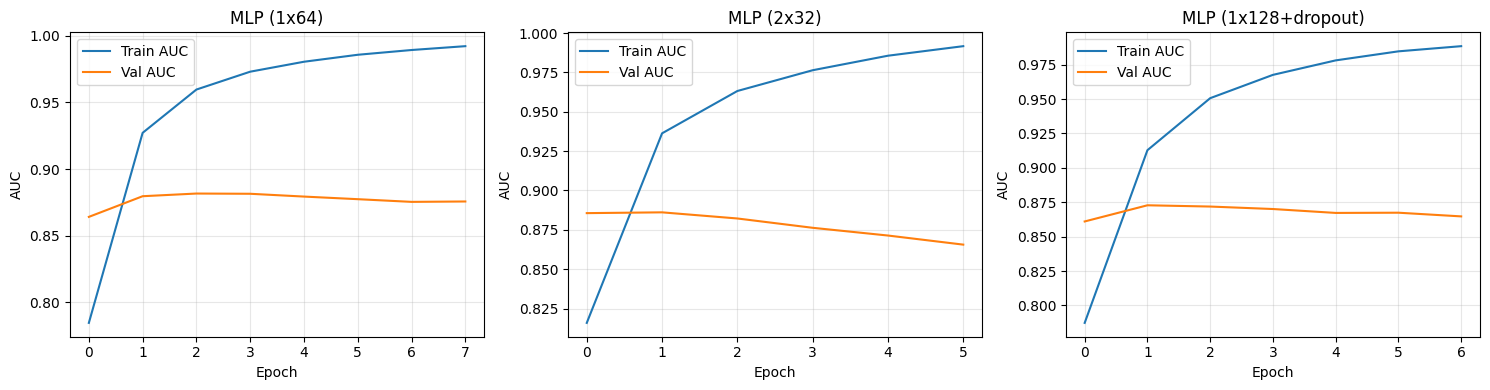

In [85]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

histories = [history_v1, history_v2, history_v3]
titles = ['MLP (1x64)', 'MLP (2x32)', 'MLP (1x128+dropout)']

for ax, hist, title in zip(axes, histories, titles):
    auc_key = next((k for k in hist.history.keys() if 'auc' in k.lower() and 'val' not in k), 'auc')
    val_auc_key = next((k for k in hist.history.keys() if 'auc' in k.lower() and 'val' in k), 'val_auc')

    ax.plot(hist.history[auc_key], label='Train AUC')
    ax.plot(hist.history[val_auc_key], label='Val AUC')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('AUC')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [93]:
_, X_val, _, y_val = train_test_split(
    X_train, y_train, 
    test_size=0.2, 
    random_state=RANDOM_SEED,
    stratify=y_train
)

mlp_models = [
    ('MLP (1x64)', mlp_v1),
    ('MLP (2x32)', mlp_v2),
    ('MLP (1x128 + dropout)', mlp_v3)
]


for name, model in mlp_models:
    y_probs = model.predict(X_val, verbose=0)
    y_preds = (y_probs > 0.5).astype(int)
    f1 = f1_score(y_val, y_preds)
    print(f"{name:<25} F1-Score: {f1:.4f}")

MLP (1x64)                F1-Score: 0.8299
MLP (2x32)                F1-Score: 0.7666
MLP (1x128 + dropout)     F1-Score: 0.7940
